## CIS 580, Machine Perception, Spring 2025



### Final Project B
#### Due: April 13 2025, 11:59pm ET


# Instructions
Configuration Instructions: Create a folder in your Google Drive and place inside this .ipynb file. Open the jupyter notebook with Google Colab. Refrain from using a GPU during implementing and testing the whole thing. You should switch to a GPU runtime only when performing the final training (of the 2D image or the NeRF) to avoid GPU usage runouts.

Python Environment Instruction: Refer to the requirements.txt file.

Submission Instructions: Split the code into 2 seperate files: 'part1_code.py', 'part2_code.py' and only keep libraries, classes and functions (refer to the examples). Submit 6 files in total: 'part1_code.py', 'part2_code.py', 'model_2d_0freq.pt', 'model_2d_2freq.pt', 'model_2d_6freq.pt', 'model_nerf.pt'.

# Part 1: Fitting a 2D Image

In [3]:
import numpy as np
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import imageio.v2 as imageio
import time
import gdown
%matplotlib inline
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


We first download the image from the web. We normalize the image so the pixels are in between the range of [0,1].

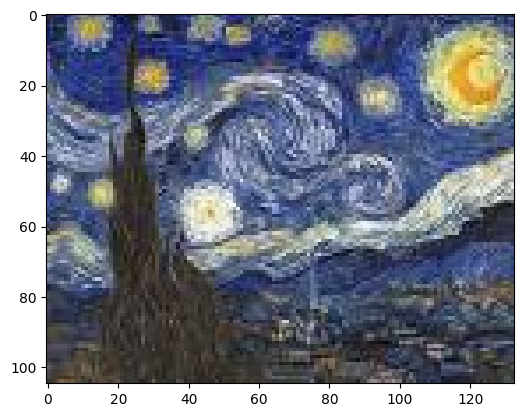

In [4]:
# Load painting image
painting = imageio.imread("starry_night.jpg")
painting = torch.from_numpy(np.array(painting, dtype=np.float32)/255.).to(device)
height_painting, width_painting = painting.shape[:2]
plt.imshow(painting.cpu())


1.1 Complete the function positional_encoding()

In [5]:
def positional_encoding(x, num_frequencies=6, incl_input=True):

    """
    Apply positional encoding to the input.

    Args:
    x (torch.Tensor): Input tensor to be positionally encoded.
      The dimension of x is [N, D], where N is the number of input coordinates,
      and D is the dimension of the input coordinate.
    num_frequencies (optional, int): The number of frequencies used in
     the positional encoding (default: 6).
    incl_input (optional, bool): If True, concatenate the input with the
        computed positional encoding (default: True).

    Returns:
    (torch.Tensor): Positional encoding of the input tensor. shape: [N, D*(2*num_frequencies+1)] or [N, D*2*num_frequencies] if incl_input is False.
    """

    results = []
    if incl_input:
        results.append(x)
    #############################  TODO 1(a) BEGIN  ############################
    # encode input tensor and append the encoded tensor to the list of results.
    frequencies = 2 ** torch.arange(num_frequencies, dtype=torch.float32, device=x.device) * math.pi

    # Apply sin and cos to each frequency
    for freq in frequencies:
        results.append(torch.sin(x * freq))
        results.append(torch.cos(x * freq))


    #############################  TODO 1(a) END  ##############################
    return torch.cat(results, dim=-1)

1.2 Complete the class model_2d() that will be used to fit the 2D image.


In [6]:
class model_2d(nn.Module):

    """
    Define a 2D model comprising of three fully connected layers,
    two relu activations and one sigmoid activation.
    """

    def __init__(self, filter_size=128, num_frequencies=6):
        super().__init__()
        #############################  TODO 1(b) BEGIN  ############################
        # for autograder compliance, please follow the given naming for your layers
        self.layer_in = nn.Linear((num_frequencies*2+1)*2, filter_size)
        self.act1 = nn.ReLU()
        self.layer = nn.Linear(filter_size, filter_size)
        self.act2 = nn.ReLU()
        self.layer_out = nn.Linear(filter_size, 3)
        self.out_act = nn.Sigmoid()



        #############################  TODO 1(b) END  ##############################

    def forward(self, x):
        #############################  TODO 1(b) BEGIN  ############################
        # example of forward through a layer: y = self.layer_in(x)
        x = self.layer_in(x)
        x = self.act1(x)
        x = self.layer(x)
        x = self.act2(x)
        x = self.layer_out(x)
        x = self.out_act(x)

        #############################  TODO 1(b) END  ##############################
        return x

In [7]:
def normalize_coord(height, width, num_frequencies=6):

    """
    Creates the 2D normalized coordinates, and applies positional encoding to them

    Args:
    height (int): Height of the image
    width (int): Width of the image
    num_frequencies (optional, int): The number of frequencies used in
      the positional encoding (default: 6).

    Returns:
    (torch.Tensor): Returns the 2D normalized coordinates (range in [0, 1]) after applying positional encoding to them. Shape: [height*width, D*(2*num_frequencies+1)].
    """

    #############################  TODO 1(c) BEGIN  ############################
    # Create the 2D normalized coordinates, and apply positional encoding to them
    x = torch.linspace(0, 1, width)
    y = torch.linspace(0, 1, height)
    yy, xx = torch.meshgrid(y, x, indexing='ij')  # [H, W]

    coords = torch.stack([xx, yy], dim=-1).reshape(-1, 2)  # [H*W, 2]

    embedded_coordinates = torch.zeros((height*width, (num_frequencies*2+1)*2))
    embedded_coordinates[:] = positional_encoding(coords, num_frequencies=num_frequencies, incl_input=True)


    ... # apply positional encoding to x and y and store the result in embedded_coordinates


    #############################  TODO 1(c) END  ############################

    return embedded_coordinates

You need to complete 1.1 and 1.2 first before completing the train_2d_model function. Don't forget to transfer the completed functions from 1.1 and 1.2 to the part1.py file and upload it to the autograder.

Fill the gaps in the train_2d_model() function to train the model to fit the 2D image.

In [8]:
def train_2d_model(test_img, num_frequencies, device, model=model_2d, positional_encoding=positional_encoding, show=True):

    # Optimizer parameters
    lr = 5e-4
    iterations = 10000
    height, width = test_img.shape[:2]

    # Number of iters after which stats are displayed
    display = 2000

    # Define the model and initialize its weights.
    model2d = model(num_frequencies=num_frequencies)
    model2d.to(device)

    def weights_init(m):
        if isinstance(m, nn.Linear):
            torch.nn.init.xavier_uniform_(m.weight)

    model2d.apply(weights_init)

    #############################  TODO 1(c) BEGIN  ############################
    # Define the optimizer
    optimizer = torch.optim.Adam(model2d.parameters(), lr=lr)

    #############################  TODO 1(c) END  ############################

    # Seed RNG, for repeatability
    seed = 5670
    torch.manual_seed(seed)
    np.random.seed(seed)

    # Lists to log metrics etc.
    psnrs = []
    iternums = []

    t = time.time()
    t0 = time.time()

    #############################  TODO 1(c) BEGIN  ############################
    # Create the 2D normalized coordinates, and apply positional encoding to them
    embedded_coordinates = normalize_coord(height, width, num_frequencies)

    #############################  TODO 1(c) END  ############################

    for i in range(iterations+1):
        optimizer.zero_grad()
        #############################  TODO 1(c) BEGIN  ############################
        # Run one iteration


        # Compute mean-squared error between the predicted and target images. Backprop!
        pred = model2d.forward(embedded_coordinates.to(device))
        pred = pred.reshape(height, width, 3)
        loss = torch.mean((pred - test_img)**2)
        loss.backward()
        optimizer.step()

        #############################  TODO 1(c) END  ############################

        # Display images/plots/stats
        if i % display == 0 and show:
            #############################  TODO 1(c) BEGIN  ############################
            # Calculate psnr
            psnr = 10 * torch.log10(1 / loss)

            #############################  TODO 1(c) END  ############################

            print("Iteration %d " % i, "Loss: %.4f " % loss.item(), "PSNR: %.2f" % psnr.item(), \
                "Time: %.2f secs per iter" % ((time.time() - t) / display), "%.2f secs in total" % (time.time() - t0))
            t = time.time()

            psnrs.append(psnr.item())
            iternums.append(i)

            plt.figure(figsize=(13, 4))
            plt.subplot(131)
            plt.imshow(pred.detach().cpu().numpy())
            plt.title(f"Iteration {i}")
            plt.subplot(132)
            plt.imshow(test_img.cpu().numpy())
            plt.title("Target image")
            plt.subplot(133)
            plt.plot(iternums, psnrs)
            plt.title("PSNR")
            plt.show()

    print('Done!')
    torch.save(model2d.state_dict(),'model_2d_' + str(num_frequencies) + 'freq.pt')
    plt.imsave('van_gogh_' + str(num_frequencies) + 'freq.png',pred.detach().cpu().numpy())
    return pred.detach().cpu()

Train the model to fit the given image without applying positional encoding to the input, and by applying positional encoding of two different frequencies to the input; L = 2 and L = 6.

In [9]:
import math

Iteration 0  Loss: 0.0472  PSNR: 13.26 Time: 0.00 secs per iter 1.01 secs in total


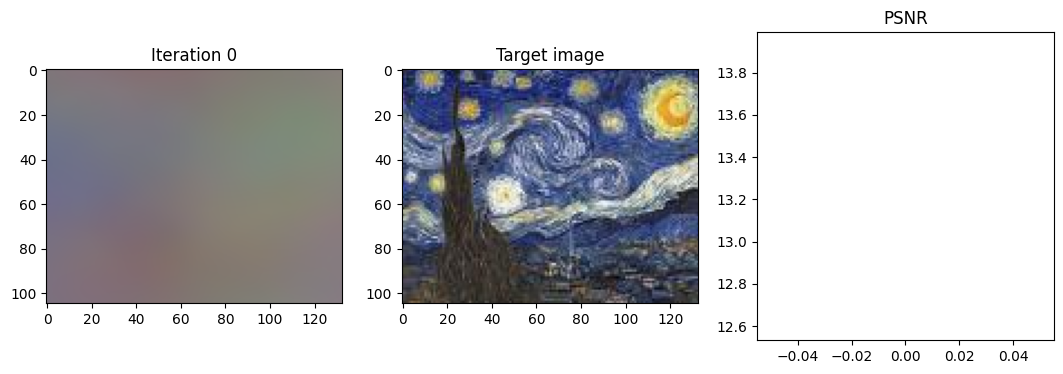

Iteration 2000  Loss: 0.0086  PSNR: 20.63 Time: 0.00 secs per iter 5.24 secs in total


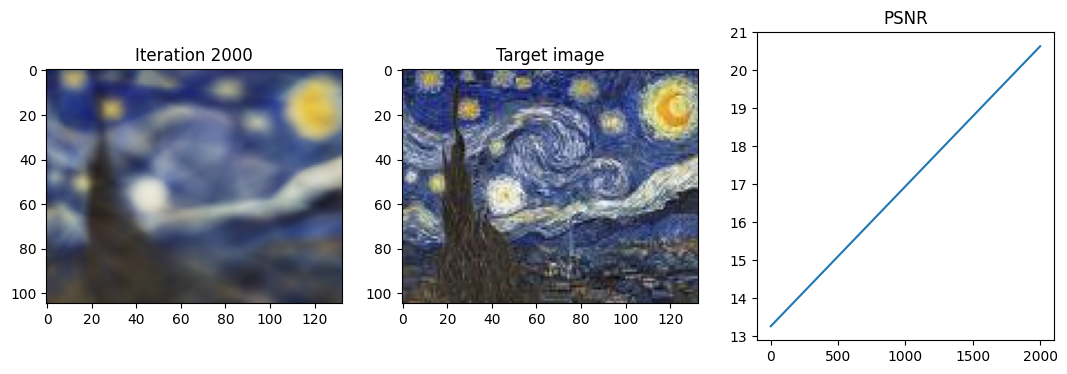

Iteration 4000  Loss: 0.0078  PSNR: 21.09 Time: 0.00 secs per iter 9.12 secs in total


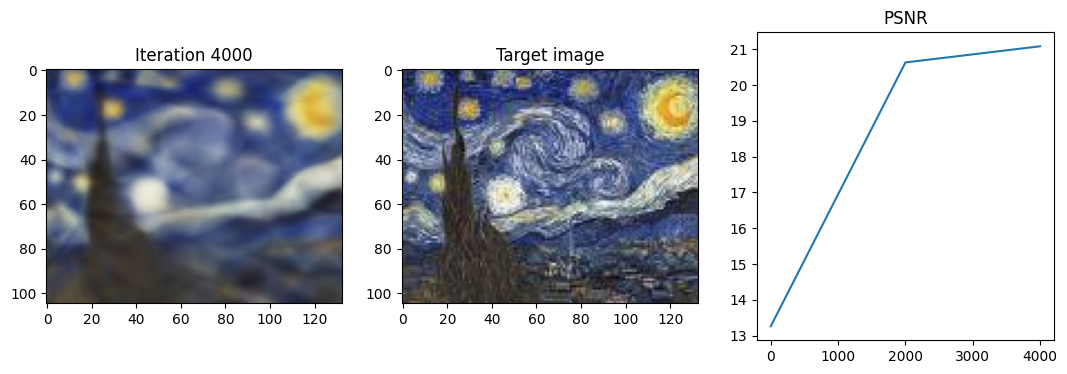

Iteration 6000  Loss: 0.0074  PSNR: 21.31 Time: 0.00 secs per iter 13.56 secs in total


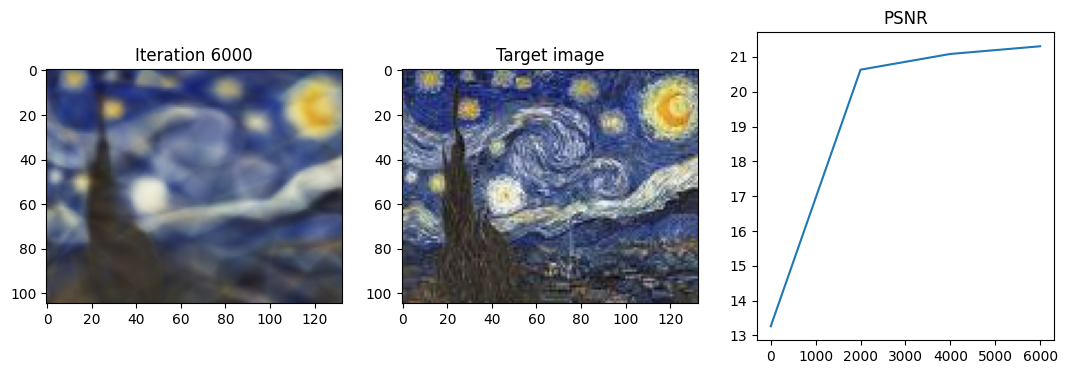

Iteration 8000  Loss: 0.0071  PSNR: 21.46 Time: 0.00 secs per iter 17.50 secs in total


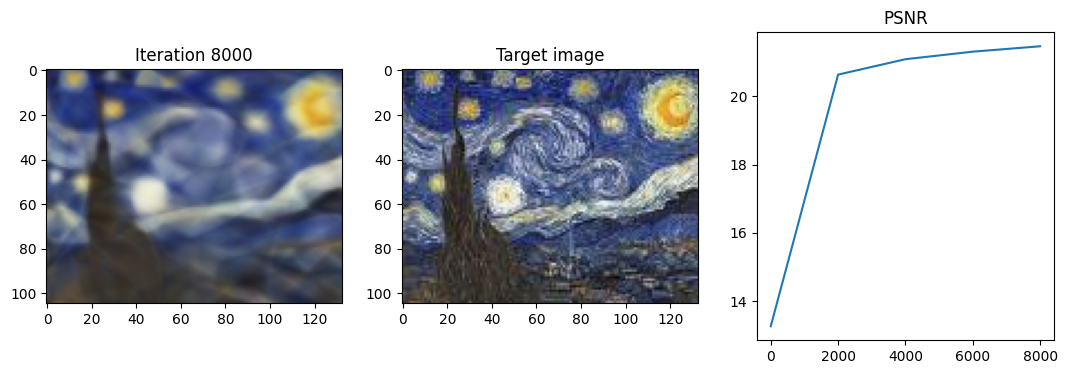

Iteration 10000  Loss: 0.0070  PSNR: 21.58 Time: 0.00 secs per iter 21.78 secs in total


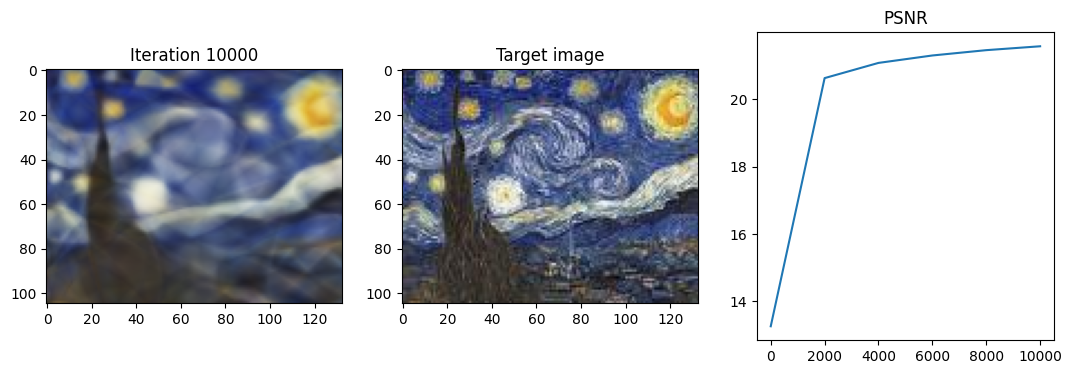

Done!


In [10]:
_ = train_2d_model(test_img=painting, num_frequencies=2, device=device)

# Part 2: Fitting a 3D Image

In [11]:
import os
import gdown
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import torch.nn.functional as F
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#device = torch.device("mps") # Uncomment this line to use macbook's mps
print(device)

cuda


Here, we load the data that is comprised by the images, the R and T matrices of each camera position with respect to the world coordinates and the intrinsics parameters K of the camera.

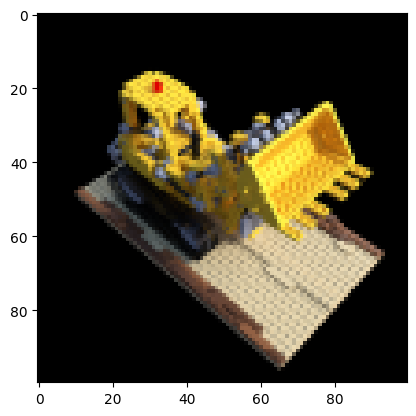

In [12]:
# Load input images, poses, and intrinsics
data = np.load("lego_data.npz")

# Images
images = data["images"]

# Height and width of each image
height, width = images.shape[1:3]

# Camera extrinsics (poses)
poses = data["poses"]
poses = torch.from_numpy(poses).to(device)


# Camera intrinsics
intrinsics = data["intrinsics"]
intrinsics = torch.from_numpy(intrinsics).to(device)

# Hold one image out (for test).
test_image, test_pose = images[101], poses[101]
test_image = torch.from_numpy(test_image).to(device)

# Map images to device
images = torch.from_numpy(images[:100, ..., :3]).to(device)

plt.imshow(test_image.detach().cpu().numpy())
plt.show()

2.1 Complete the following function that calculates the rays that pass through all the pixels of an HxW image

In [13]:

def get_rays(height, width, intrinsics, w_R_c, w_T_c):
    """
    Compute the origin and direction of rays passing through all pixels of an image (one ray per pixel).

    Args:
    height: the height of an image.
    width: the width of an image.
    intrinsics: camera intrinsics matrix of shape (3, 3).
    w_R_c: Rotation matrix of shape (3,3) from camera to world coordinates.
    w_T_c: Translation vector of shape (3,1) that transforms

    Returns:
    ray_origins (torch.Tensor): A tensor of shape (height, width, 3) denoting the centers of
      each ray. Note that despite that all rays share the same origin, here we ask you to return
      the ray origin for each ray as (height, width, 3).
    ray_directions (torch.Tensor): A tensor of shape (height, width, 3) denoting the
      direction of each ray.
    """

    device = intrinsics.device
    ray_directions = torch.zeros((height, width, 3), device=device)
    ray_origins = torch.zeros((height, width, 3), device=device)

    # Get intrinsics parameters
    f_x = intrinsics[0, 0]
    f_y = intrinsics[1, 1]
    c_x = intrinsics[0, 2]
    c_y = intrinsics[1, 2]

    # Create grid of pixel coordinates
    v, u = torch.meshgrid(torch.arange(0, width, device=device),
                          torch.arange(0, height, device=device))

    # Normalize pixel coordinates
    x_normalized = (u - c_x) / f_x
    y_normalized = (v - c_y) / f_y


    # Stack normalized coordinates to form rays
    ray_directions[..., 0] = x_normalized
    ray_directions[..., 1] = y_normalized
    ray_directions[..., 2] = 1.0

    # Convert ray directions to world coordinates
    ray_directions = ray_directions @ w_R_c.T
    ray_directions = ray_directions / torch.norm(ray_directions, dim=-1, keepdim=True)

    # Compute ray origins in world coordinates
    ray_origins = w_T_c.view(1, 1, 3).expand(height, width, 3)

    return ray_origins, ray_directions

Complete the next function to visualize how is the dataset created. You will be able to see from which point of view each image has been captured for the 3D object. What we want to achieve here, is to being able to interpolate between these given views and synthesize new realistic views of the 3D object.

/usr/local/lib/python3.11/dist-packages/torch/functional.py:539: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:3637.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


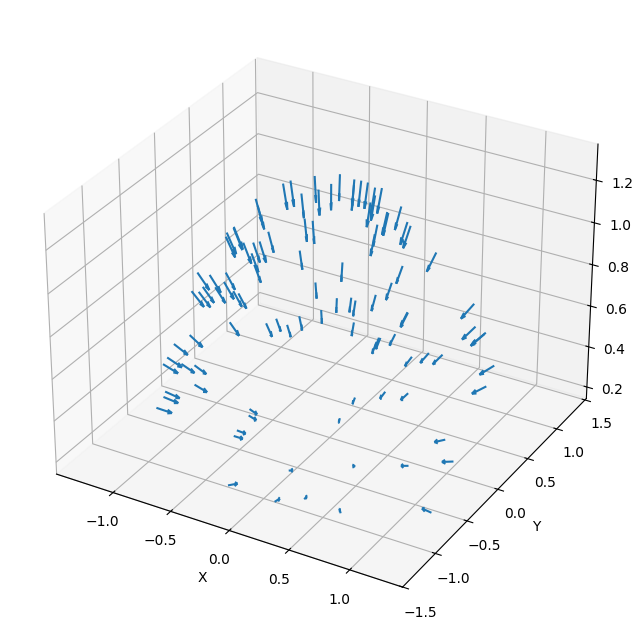

In [14]:

def plot_all_poses(poses):

    #############################  TODO 2.1 BEGIN  ############################
    origins = []
    directions = []
    for pose in poses:
        # pose = torch.from_numpy(pose).to(device)
        w_R_c = pose[:3, :3]
        w_T_c = pose[:3, 3]
        ray_origins, ray_directions = get_rays(height, width, intrinsics.to(device), w_R_c, w_T_c)

        origins.append(ray_origins.cpu()[height//2, width//2]) # Append the origin of the ray passing through the center of the image
        directions.append(ray_directions.cpu()[height//2, width//2]) # Append the direction of the ray passing through the center of the image
    origins = torch.stack(origins)
    directions = torch.stack(directions)
    #############################  TODO 2.1 END  ############################

    ax = plt.figure(figsize=(12, 8)).add_subplot(projection='3d')
    _ = ax.quiver(origins[..., 0].flatten(),
                  origins[..., 1].flatten(),
                  origins[..., 2].flatten(),
                  directions[..., 0].flatten(),
                  directions[..., 1].flatten(),
                  directions[..., 2].flatten(), length=0.12, normalize=True)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('z')
    plt.show()

plot_all_poses(poses)


2.2 Complete the following function to implement the sampling of points along a given ray.

In [15]:

def stratified_sampling(ray_origins, ray_directions, near, far, samples):

    """
    Sample 3D points on the given rays. The near and far variables indicate the bounds of sampling range.

    Args:
    ray_origins: Origin of each ray in the "bundle" as returned by the
      get_rays() function. Shape: (height, width, 3).
    ray_directions: Direction of each ray in the "bundle" as returned by the
      get_rays() function. Shape: (height, width, 3).
    near: The 'near' extent of the bounding volume.
    far:  The 'far' extent of the bounding volume.
    samples: Number of samples to be drawn along each ray.

    Returns:
    ray_points: Query 3D points along each ray. Shape: (height, width, samples, 3).
    depth_points: Sampled depth values along each ray. Shape: (height, width, samples).
    """

    #############################  TODO 2.2 BEGIN  ############################
    device = ray_origins.device
    height, width, _ = ray_origins.shape

    # Sample uniformly between near and far for each ray
    t_vals = torch.linspace(0., 1., steps=samples, device=device)
    depth_points = near * (1. - t_vals) + far * t_vals  # (samples,)
    depth_points = depth_points.expand(height, width, samples)  # (height, width, samples)

    # Compute 3D points
    ray_points = ray_origins.unsqueeze(2) + ray_directions.unsqueeze(2) * depth_points.unsqueeze(-1)



    #############################  TODO 2.2 END  ############################
    return ray_points, depth_points

2.3 Define the network architecture of NeRF along with a function that divided data into chunks to avoid memory leaks during training.

In [16]:
class nerf_model(nn.Module):

    """
    Define a NeRF model comprising eight fully connected layers and following the
    architecture described in the NeRF paper.
    """

    def __init__(self, filter_size=256, num_x_frequencies=6, num_d_frequencies=3):
        super().__init__()

        #############################  TODO 2.3 BEGIN  ############################
        # for autograder compliance, please follow the given naming for your layers
        input_x_dim = (num_x_frequencies * 2 + 1) * 3  # Positional encoding for x
        input_d_dim = (num_d_frequencies * 2 + 1) * 3  # Positional encoding for d

        self.layers = nn.ModuleDict({
            'layer_1': nn.Linear(input_x_dim, filter_size),
            'layer_2': nn.Linear(filter_size, filter_size),
            'layer_3': nn.Linear(filter_size, filter_size),
            'layer_4': nn.Linear(filter_size, filter_size),
            'layer_5': nn.Linear(filter_size + input_x_dim, filter_size),  # Skip connection
            'layer_6': nn.Linear(filter_size, filter_size),
            'layer_7': nn.Linear(filter_size, filter_size),
            'layer_8': nn.Linear(filter_size, filter_size),
            'sigma_output': nn.Linear(filter_size, 1),                     # Output sigma
            'feature_layer': nn.Linear(filter_size, filter_size),
            'direction_layer': nn.Linear(filter_size + input_d_dim, filter_size // 2),
            'rgb_output': nn.Linear(filter_size // 2, 3),                  # Output RGB
        })

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

        #############################  TODO 2.3 END  ############################


    def forward(self, x, d):
        #############################  TODO 2.3 BEGIN  ############################
        # example of forward through a layer: y = self.layers['layer_1'](x)
        x_input = x

        x = self.relu(self.layers['layer_1'](x))
        x = self.relu(self.layers['layer_2'](x))
        x = self.relu(self.layers['layer_3'](x))
        x = self.relu(self.layers['layer_4'](x))

        # Skip connection
        x = torch.cat([x, x_input], dim=-1)
        x = self.relu(self.layers['layer_5'](x))
        x = self.relu(self.layers['layer_6'](x))
        x = self.relu(self.layers['layer_7'](x))
        x = self.relu(self.layers['layer_8'](x))

        # Output density (sigma)
        sigma = self.layers['sigma_output'](x)

        # Extract feature for color
        feature = self.layers['feature_layer'](x)

        # Concatenate with direction input
        feature_and_d = torch.cat([feature, d], dim=-1)
        h = self.relu(self.layers['direction_layer'](feature_and_d))

        # Output RGB
        rgb = self.sigmoid(self.layers['rgb_output'](h))
        #############################  TODO 2.3 END  ############################
        return rgb, sigma

In [17]:
def get_batches(ray_points, ray_directions, num_x_frequencies, num_d_frequencies):

    def get_chunks(inputs, chunksize = 2**15):
        """
        This fuction gets an array/list as input and returns a list of chunks of the initial array/list
        """

        return [inputs[i:i + chunksize] for i in range(0, inputs.shape[0], chunksize)]

    def positional_encoding(x, num_frequencies):
        freq_bands = 2.0 ** torch.arange(num_frequencies, device=x.device) * torch.pi
        x_encoded = [x]
        for freq in freq_bands:
            x_encoded.append(torch.sin(freq * x))
            x_encoded.append(torch.cos(freq * x))
        return torch.cat(x_encoded, dim=-1)



    """
    This function returns chunks of the ray points and directions to avoid memory errors with the
    neural network. It also applies positional encoding to the input points and directions before
    dividing them into chunks, as well as normalizing and populating the directions.
    Return Shape:   ray_points_batches: List of chunks of ray points. Each chunk has shape (H, W, S, 3*(2*num_x_frequencies+1)).
                    ray_directions_batches: List of chunks of ray directions. Each chunk has shape (H, W, S, 3*(2*num_x_frequencies+1)).
    """
    #############################  TODO 2.3 BEGIN  ############################
    # Apply positional encoding to the ray points and directions (you may nomalize the directions here)
    # repeat the directions to match the dimension and number of points S
    H, W, S, _ = ray_points.shape

    ray_directions = ray_directions / torch.norm(ray_directions, dim=-1, keepdim=True)

    # Repeat directions along the sample dimension S
    ray_directions = ray_directions.unsqueeze(2).expand(-1, -1, S, -1)  # shape (H, W, S, 3)

    # Positional encoding for ray points and directions
    ray_points = positional_encoding(ray_points, num_x_frequencies)
    ray_directions = positional_encoding(ray_directions, num_d_frequencies)

    # Flatten (H, W, S) to (H * W * S, ...)
    ray_points = ray_points.view(-1, ray_points.shape[-1])
    ray_directions = ray_directions.view(-1, ray_directions.shape[-1])

    # Divide the ray points and directions into chunks
    ray_directions_batches = get_chunks(ray_directions)
    ray_points_batches = get_chunks(ray_points)


    #############################  TODO 2.3 END  ############################

    return ray_points_batches, ray_directions_batches

2.4 Compute the compositing weights of samples on camera ray and then complete the volumetric rendering procedure to reconstruct a whole RGB image from the sampled points and the outputs of the neural network.

In [18]:
def volumetric_rendering(rgb, s, depth_points):

    """
    Differentiably renders a radiance field, given the origin of each ray in the
    "bundle", and the sampled depth values along them.

    Args:
    rgb: RGB color at each query location (X, Y, Z). Shape: (height, width, samples, 3).
    s: Volume density sigma at each query location (X, Y, Z). Shape: (height, width, samples).
    depth_points: Sampled depth values along each ray. Shape: (height, width, samples).

    Returns:
    rec_image: The reconstructed image after applying the volumetric rendering to every pixel.
    Shape: (height, width, 3)
    """

    #############################  TODO 2.4 BEGIN  ############################

    H, W, N = s.shape
    # Compute the weights of each sample
    # Step 1: Apply ReLU to density
    s = nn.functional.relu(s)

    # Step 2: Compute delta between adjacent depth points
    delta = torch.zeros((H, W, N), device=device)
    delta[:, :, :-1] = depth_points[:, :, 1:] - depth_points[:, :, :-1]
    delta[:, :, -1] = 1e9  # Very large value for the last delta

    # Step 3: Compute alpha (probability of termination at a sample)
    alpha = 1.0 - torch.exp(-s * delta)

    # Step 4: Compute transmittance T
    T = torch.cumprod(
        torch.cat([torch.ones((H, W, 1), device=device), 1.0 - alpha + 1e-10], dim=-1),
        dim=-1
    )
    T = T[:, :, :-1]  # Shift to align with alpha

    # Step 5: Compute weights
    weights = alpha * T

    # Step 6: Weighted sum of rgb using weights
    rec_image = (weights.unsqueeze(-1) * rgb).sum(dim=2)

    # Step 7: Clamp to [0,1]
    rec_image = rec_image.clamp(0, 1)

    #############################  TODO 2.4 END  ############################

    return rec_image


To test and visualize your implementation, independently of the previous and next steps of the
NeRF pipeline, you can load the sanity_volumentric.pt file, run your implementation of the volumetric function and expect to see the figure provided in the handout.


In [19]:
# url = "https://drive.google.com/file/d/1ag6MqSh3h4KY10Mcx5fKxt9roGNLLILK/view?usp=sharing"
# gdown.download(url=url, output='sanity_volumentric.pt', quiet=False, fuzzy=True)
rbd = torch.load('sanity_volumentric.pt')

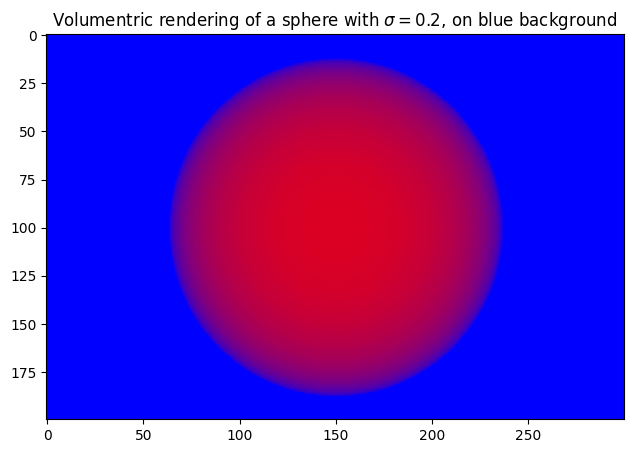

In [20]:
r = rbd['rgb'].float().to(device)
s = rbd['sigma'].float().to(device)
depth_points = rbd['depth_points'].float().to(device)
rec_image = volumetric_rendering(r, s, depth_points)

plt.figure(figsize=(10, 5))
plt.imshow(rec_image.detach().cpu().numpy())
plt.title(f'Volumentric rendering of a sphere with $\\sigma={0.2}$, on blue background')
plt.show()

2.5 Combine everything together. Given the pose position of a camera, compute the camera rays and sample the 3D points along these rays. Divide those points into batches and feed them to the neural network. Concatenate them and use them for the volumetric rendering to reconstructed the final image.

In [21]:
def one_forward_pass(height, width, intrinsics, pose, near, far, samples, model, num_x_frequencies, num_d_frequencies):

    #############################  TODO 2.5 BEGIN  ############################

    device = intrinsics.device

    # Compute all the rays from the image
    w_R_c = pose[:3, :3]
    w_T_c = pose[:3, 3].view(3, 1)
    ray_origins, ray_directions = get_rays(height, width, intrinsics, w_R_c, w_T_c)

    # Sample points along the rays
    ray_points, depth_points = stratified_sampling(ray_origins, ray_directions, near, far, samples)

    # Divide data into batches to avoid memory errors
    ray_points_batches, ray_directions_batches = get_batches(ray_points, ray_directions, num_x_frequencies, num_d_frequencies)


    #forward pass the batches and concatenate the outputs at the end
    rgb = None
    sigma = None
    for i in range(len(ray_points_batches)):
        rgb_batch, sigma_batch = model(ray_points_batches[i], ray_directions_batches[i])
        if rgb is None:
            rgb = rgb_batch
            sigma = sigma_batch
        else:
            rgb = torch.cat((rgb, rgb_batch), 0)
            sigma = torch.cat((sigma, sigma_batch), 0)
    rgb = rgb.reshape(height, width, samples, 3)
    sigma = sigma.reshape(height, width, samples)


    # Apply volumetric rendering to obtain the reconstructed image
    rgb = rgb.reshape(height, width, samples, 3)
    sigma = sigma.reshape(height, width, samples)

    # Apply volumetric rendering to obtain the reconstructed image
    rec_image = volumetric_rendering(rgb, sigma, depth_points)


    #############################  TODO 2.5 END  ############################

    return rec_image

If you manage to **pass the autograder for all the previous functions**, then it is time to train a NeRF! We provide the hyperparameters for you, we initialize the NeRF model and its weights, and we define a couple lists that will be needed to store results.

In [22]:
num_x_frequencies = 10
num_d_frequencies = 4
learning_rate  = 5e-4
iterations = 3000
samples = 64
display = 25
near = 0.667
far = 2

model = nerf_model(num_x_frequencies=num_x_frequencies,num_d_frequencies=num_d_frequencies).to(device)

def weights_init(m):
    if isinstance(m, torch.nn.Linear):
        torch.nn.init.xavier_uniform_(m.weight)
model.apply(weights_init)

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

psnrs = []
iternums = []

t = time.time()
t0 = time.time()

In [23]:
print(torch.backends.mps.is_available())

False


  0%|          | 0/3001 [00:00<?, ?it/s]

Iteration 0  Loss: 0.1656  PSNR: 7.81  Time: 0.05 secs per iter,  0.02 mins in total


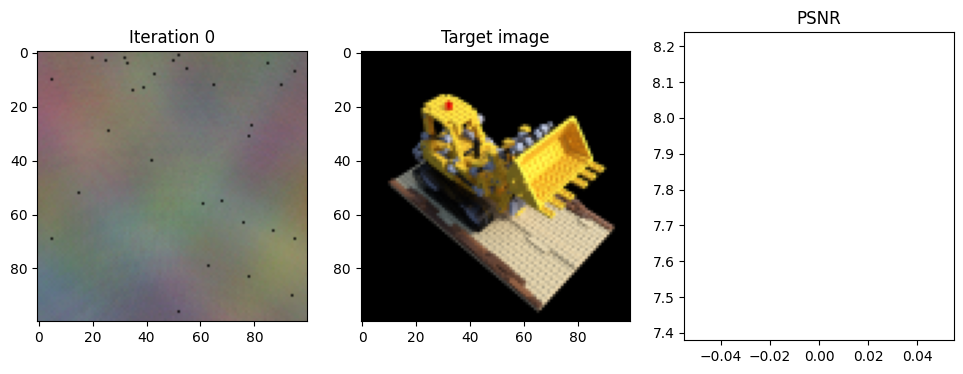

  0%|          | 8/3001 [00:07<48:54,  1.02it/s]


KeyboardInterrupt: 

In [24]:
import tqdm
for i in tqdm.trange(iterations+1):

    #############################  TODO 2.6 BEGIN  ############################

    #choose randomly a picture for the forward pass
    idx = np.random.randint(0, 100)
    pose = poses[idx]
    image = images[idx]
    image = image.to(device)
    pose = pose.to(device)



    # Run one iteration of NeRF and get the rendered RGB image.
    rec_image = one_forward_pass(height, width, intrinsics, pose, near, far, samples, model, num_x_frequencies, num_d_frequencies)



    # Compute mean-squared error between the predicted and target images. Backprop!
    optimizer.zero_grad()
    loss = torch.mean((rec_image - image)**2)
    loss.backward()
    optimizer.step()




    #############################  TODO 2.6 END  ############################

    # Display images/plots/stats
    if i % display == 0:
        with torch.no_grad():
        #############################  TODO 2.6 BEGIN  ############################
            # Render the held-out view
            test_rec_image = one_forward_pass(height, width, intrinsics, test_pose, near, far, samples, model, num_x_frequencies, num_d_frequencies)


        #calculate the loss and the psnr between the original test image and the reconstructed one.
        loss = torch.mean((test_rec_image - image)**2)
        psnr = 10 * torch.log10(1 / loss)

        #############################  TODO 2.6 END  ############################

        print("Iteration %d " % i, "Loss: %.4f " % loss.item(), "PSNR: %.2f " % psnr.item(), \
                "Time: %.2f secs per iter, " % ((time.time() - t) / display), "%.2f mins in total" % ((time.time() - t0)/60))

        t = time.time()
        psnrs.append(psnr.item())
        iternums.append(i)

        plt.figure(figsize=(16, 4))
        plt.subplot(141)
        plt.imshow(test_rec_image.detach().cpu().numpy())
        plt.title(f"Iteration {i}")
        plt.subplot(142)
        plt.imshow(test_image.detach().cpu().numpy())
        plt.title("Target image")
        plt.subplot(143)
        plt.plot(iternums, psnrs)
        plt.title("PSNR")
        plt.show()

plt.imsave('test_lego.png',test_rec_image.detach().cpu().numpy())
torch.save(model.state_dict(),'model_nerf.pt')
print('Done!')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')